# ShowDiffraction

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/electronmicroscopy/quantem.widget/blob/main/docs/tutorials/showdiffraction.ipynb)

`ShowDiffraction` is an interactive d-spacing analyzer for 2D diffraction patterns and 3D pattern stacks. It accepts a NumPy array, a PyTorch tensor, or a quantem `Dataset`. Auto runs center refinement, ring detection, phase calibration, fitting, and indexing, and Phase selects a library or custom phase.

In [1]:
import numpy as np

from quantem.widget import ShowDiffraction
from quantem.widget import Phase

rng = np.random.default_rng(0)
size = 256
center = (size - 1) / 2
rows, cols = np.mgrid[0:size, 0:size]
radius = np.hypot(rows - center, cols - center)


def bragg_lattice(rotation_deg=0.0, spacing_px=28.0):
    angle = np.deg2rad(rotation_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    pattern = np.zeros((size, size), np.float32)
    for h in range(-4, 5):
        for k in range(-4, 5):
            spot_row = center + (h * cos_a - k * sin_a) * spacing_px
            spot_col = center + (h * sin_a + k * cos_a) * spacing_px
            amplitude = 6.0 if h == 0 and k == 0 else 1.0 / (1 + 0.4 * (h * h + k * k))
            pattern += amplitude * np.exp(-((rows - spot_row) ** 2 + (cols - spot_col) ** 2) / 8.0)
    return rng.poisson(1000.0 * (pattern + 0.05)).astype(np.float32)  # shot noise


single_crystal = bragg_lattice()
tilt_series = np.stack([bragg_lattice(angle) for angle in (0, 4, 8, 12)]).astype(np.float32)

ring_radii_px = (34.0, 55.0, 78.0, 96.0)
polycrystalline = 3.0 * np.exp(-(radius ** 2) / 32.0)
for ring_radius in ring_radii_px:
    polycrystalline += 2.0 * np.exp(-((radius - ring_radius) ** 2) / 9.68)
polycrystalline = rng.poisson(100.0 * (polycrystalline + 0.05)).astype(np.float32)

size_m = 512
center_m = (size_m - 1) / 2
m_rows, m_cols = np.mgrid[0:size_m, 0:size_m]
m_radius = np.hypot(m_rows - center_m, m_cols - center_m)
magnetite_pattern = 4.0 * np.exp(-(m_radius ** 2) / 80.0)
k_synth = 0.004
for d_ref, strength, width in [
    (2.967, 1.7, 3.0),
    (2.532, 1.3, 3.5),
    (2.099, 1.0, 4.0),
    (1.715, 0.8, 4.5),
    (1.485, 0.55, 5.0),
]:
    ring_radius = 1.0 / (d_ref * k_synth)
    magnetite_pattern += strength * np.exp(-((m_radius - ring_radius) ** 2) / (2 * width ** 2))
magnetite_pattern = rng.poisson(100.0 * (magnetite_pattern + 0.05)).astype(np.float32)

## Single-crystal spots

Use Spots or click reflections. Add a custom cubic phase, then Index Spots to fill hkl and zone axis.

In [2]:
saed = ShowDiffraction(
    single_crystal,
    center=(center, center),
    bf_radius=14,
    k_pixel_size=0.018,
    title="Single-crystal SAED",
    offline=True,
    verbose=False,
    panel_width_px=530,
)
saed.detect_spots(max_spots=12)
saed.custom_phases = [{"name": "Cubic", "a": 1.984, "absences": "none"}]
saed.phase_name = "Cubic"
saed.index_spots(Phase.from_cubic("Cubic", 1.984, absences="none"))
saed

ShowDiffraction(shape=(1, 256, 256), sampling=(1.0 Å, 0.018 1/Å), frame=0/1, spots=12, title='Single-crystal SAED')

## Polycrystalline rings

Pick a phase, then press Auto. Profile, Azim, Mask View, and Quality in the side menu show the radial profile, azimuthal intensity, excluded-region overlay, and quality checks. Fit refines ring radius and width, Fit Ellipse measures distortion, and Identify ranks phase candidates; use element filters when chemistry is known.

In [3]:
magnetite = ShowDiffraction(
    magnetite_pattern,
    title="Magnetite-like rings",
    offline=True,
    verbose=False,
    panel_width_px=530,
)
magnetite.phase_name = "Fe3O4"
magnetite.run_auto(max_rings=5)
magnetite.dp_colormap = "viridis"
magnetite


ShowDiffraction(shape=(1, 512, 512), sampling=(1.0 Å, 0.004000635020534425 1/Å), frame=0/1, title='Magnetite-like rings')

In [5]:
from quantem.widget import library_phase

expected = [library_phase(n) for n in ("Fe3O4", "γ-Fe2O3", "α-Fe2O3 (hematite)", "α-Fe")]
verified = magnetite.identify_phase(expected)

for candidate in verified:
    mean_err = candidate["mean_err"]
    error_text = "n/a" if mean_err is None else f"{100 * mean_err:.2f}%"
    print(
        f"{candidate['name']}: {candidate['matched']}/{candidate['n_obs']} lines, "
        f"mean Δd {error_text}, "
        f"missing strong {candidate['n_missing_strong']}"
    )

magnetite.identify_elements = "Fe, O"
candidates = magnetite.search_phases()
print(candidates[0]["name"])

Fe3O4: 5/5 lines, mean Δd 0.04%, missing strong None
γ-Fe2O3: 5/5 lines, mean Δd 0.57%, missing strong None
α-Fe2O3 (hematite): 4/5 lines, mean Δd 0.70%, missing strong None
α-Fe: 0/5 lines, mean Δd n/a, missing strong None
Fe3O4


## ShowEDS

In [6]:
from quantem.widget import ShowEDS
from quantem.widget.datasets import show2d_gold

rng2 = np.random.default_rng(3)
energy = np.linspace(0.1, 12.0, 600, dtype=np.float32)


def eds_peaks(line_list):
    # detector-broadened lines, 130 eV FWHM at Mn Ka
    s = np.zeros_like(energy)
    for e0, amp in line_list:
        fwhm = np.sqrt(max(2500.0 * (e0 - 5.899) + 130.0**2, 60.0**2))
        s += amp * np.exp(-((energy - e0) ** 2) / (2 * (fwhm / 2355.0) ** 2))
    return s


particle_lines = eds_peaks([(6.404, 3.0), (7.058, 0.42), (0.705, 1.4), (0.525, 5.0)])
support_lines = eds_peaks([(0.277, 2.2), (0.525, 0.3)])
grid_lines = eds_peaks([(8.041, 0.9), (8.905, 0.13), (0.930, 0.3)])
brems = 0.5 * (1 - np.exp(-((energy / 0.45) ** 2))) * np.exp(-energy / 5.0)

# real HAADF, mean-binned to a normalized mass-thickness map
haadf = show2d_gold(size="small", verbose=False).array
mass = haadf.reshape(64, 8, 64, 8).mean(axis=(1, 3))
mass = (mass - mass.min()) / (mass.max() - mass.min())

eds_cube = rng2.poisson(
    120.0 * (mass[..., None] * (particle_lines + 0.6 * brems)
             + (support_lines + grid_lines + 0.4 * brems)[None, None, :])
).astype(np.uint16)

Candidates: Cu, Fe, Pd, Cs, Tb, Tm, C, O
Top phase: Fe3O4


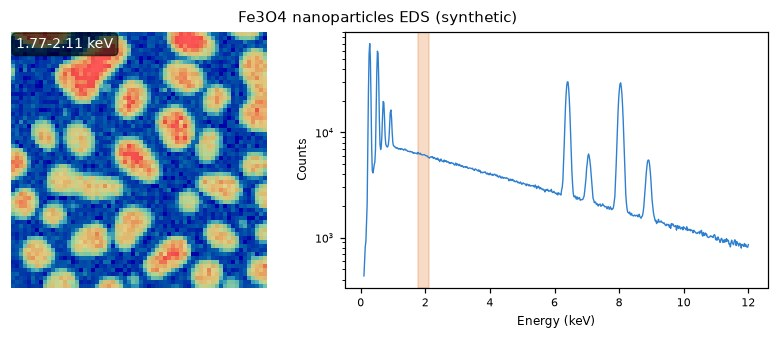

In [7]:
eds = ShowEDS(eds_cube, energy, title="Fe3O4 nanoparticles EDS (synthetic)", verbose=False)
detected = [c["element"] for c in eds.detect_elements(max_candidates=8)]
magnetite.identify_elements = ", ".join(detected)
print("Candidates:", ", ".join(detected))
print("Top phase:", magnetite.search_phases()[0]["name"])
eds

### Save

In [8]:
magnetite.summary()
magnetite.save("magnetite_state.json")

ShowDiffraction.measurements_from_state("magnetite_state.json")[:2]

# HTML export
export_path = saed.export_html("showdiffraction_saed.html", title="Single-crystal SAED")
export_path.name


Magnetite-like rings
════════════════════════════════
Frames:   1 (showing #0)
Detector: 512×512 (0.0040 1/Å/px)
Calibration: phase (rms 0.06 px)
Center:   (255.5, 255.5)  BF r=13.1 px
Spots:    0
Rings:    5
Phase:    Fe3O4 (spinel): 5/5 matched, 0.0% mean error
Display:  viridis | log


'showdiffraction_saed.html'